In [1]:
from sqlalchemy import create_engine, text
import pandas as pd

SOURCE_DB = "postgresql://postgres:@localhost:5432/DVDFilms"
TARGET_DB = "postgresql://postgres:@localhost:5432/dvdrental_analytics"

source_engine = create_engine(SOURCE_DB)
target_engine = create_engine(TARGET_DB)

# Проверка
with source_engine.connect() as conn:
    result = conn.execute(text("SELECT COUNT(*) FROM rental"))
    print(f"Всего аренд: {result.scalar()}")

Всего аренд: 16044


In [2]:
report_date = '2005-07-01'
year = 2005
month = 7

query_full = f"""
WITH 
-- Аренды за месяц
month_rentals AS (
    SELECT 
        r.rental_id,
        r.customer_id,
        r.rental_date,
        r.return_date,
        EXTRACT(DAY FROM r.return_date - r.rental_date) AS rental_days,
        p.amount,
        i.film_id
    FROM rental r
    LEFT JOIN payment p ON r.rental_id = p.rental_id
    LEFT JOIN inventory i ON r.inventory_id = i.inventory_id
    WHERE DATE_TRUNC('month', r.rental_date) = '{report_date}'::date
),

-- Топ-5 фильмов
top_films AS (
    SELECT 
        f.title,
        COUNT(*) AS cnt
    FROM month_rentals mr
    JOIN film f ON mr.film_id = f.film_id
    GROUP BY f.title
    ORDER BY cnt DESC
    LIMIT 5
),

-- Топ-5 категорий
top_cats AS (
    SELECT 
        c.name,
        COUNT(*) AS cnt
    FROM month_rentals mr
    JOIN film_category fc ON mr.film_id = fc.film_id
    JOIN category c ON fc.category_id = c.category_id
    GROUP BY c.name
    ORDER BY cnt DESC
    LIMIT 5
),

-- Фильмы без аренд в этом месяце
films_no_rent AS (
    SELECT COUNT(*) AS cnt
    FROM film f
    WHERE NOT EXISTS (
        SELECT 1 FROM month_rentals mr WHERE mr.film_id = f.film_id
    )
),

-- Новые клиенты (зарегистрировались в этом месяце)
new_cust AS (
    SELECT COUNT(*) AS cnt
    FROM customer
    WHERE DATE_TRUNC('month', create_date) = '{report_date}'::date
),

-- Отток (активные ранее, но не в этом месяце)
churned AS (
    SELECT COUNT(DISTINCT c.customer_id) AS cnt
    FROM customer c
    WHERE EXISTS (
        SELECT 1 FROM rental r 
        WHERE r.customer_id = c.customer_id 
        AND DATE_TRUNC('month', r.rental_date) < '{report_date}'::date
    )
    AND NOT EXISTS (
        SELECT 1 FROM rental r 
        WHERE r.customer_id = c.customer_id 
        AND DATE_TRUNC('month', r.rental_date) = '{report_date}'::date
    )
),

-- Метрики по возвратам
returns_metrics AS (
    SELECT 
        COUNT(*) FILTER (WHERE rental_days <= 7) AS on_time_returns,
        COUNT(*) FILTER (WHERE rental_days > 7) AS late_returns,
        COUNT(*) FILTER (WHERE return_date IS NULL 
                         AND EXTRACT(DAY FROM NOW() - rental_date) > 30) AS lost_films
    FROM month_rentals
)

SELECT 
    mr.total_rentals,
    mr.unique_customers,
    mr.avg_rental_duration,
    mr.total_revenue,
    mr.total_revenue / NULLIF(mr.total_rentals, 0) AS avg_revenue_per_rental,
    (SELECT STRING_AGG(title, ', ' ORDER BY cnt DESC, title) FROM top_films) AS top_5_films,
    (SELECT STRING_AGG(name, ', ' ORDER BY cnt DESC, name) FROM top_cats) AS top_5_categories,
    (SELECT cnt FROM films_no_rent) AS films_without_rentals,
    (SELECT cnt FROM new_cust) AS new_customers,
    (SELECT cnt FROM churned) AS churned_customers,
    mr.total_rentals::float / NULLIF(mr.unique_customers, 0) AS avg_rentals_per_customer,
    rm.on_time_returns,
    rm.late_returns,
    rm.lost_films
FROM (
    SELECT 
        COUNT(*) AS total_rentals,
        COUNT(DISTINCT customer_id) AS unique_customers,
        AVG(rental_days) AS avg_rental_duration,
        COALESCE(SUM(amount), 0) AS total_revenue
    FROM month_rentals
) mr
CROSS JOIN returns_metrics rm
"""

with source_engine.connect() as conn:
    df_metrics = pd.read_sql(text(query_full), conn)

print("Метрики за июль 2005:")
print(df_metrics.T)  # транспонируем для удобного просмотра

Метрики за июль 2005:
                                                                          0
total_rentals                                                          6709
unique_customers                                                        599
avg_rental_duration                                                4.518259
total_revenue                                                      28368.91
avg_revenue_per_rental                                             4.228486
top_5_films               SCALAWAG DUCK, GREATEST NORTH, PRIMARY GLASS, ...
top_5_categories                   Sports, Animation, Action, Drama, Sci-Fi
films_without_rentals                                                    42
new_customers                                                             0
churned_customers                                                         0
avg_rentals_per_customer                                          11.200334
on_time_returns                                                   

In [3]:
from datetime import datetime

# Подготовка строки для вставки
insert_query = text("""
    INSERT INTO monthly_report (
        report_month, report_year, report_month_num,
        total_rentals, unique_customers, avg_rental_duration,
        total_revenue, avg_revenue_per_rental,
        top_5_films, top_5_categories, films_without_rentals,
        new_customers, churned_customers, avg_rentals_per_customer,
        on_time_returns, late_returns, lost_films,
        etl_timestamp, etl_status
    ) VALUES (
        :report_month, :report_year, :report_month_num,
        :total_rentals, :unique_customers, :avg_rental_duration,
        :total_revenue, :avg_revenue_per_rental,
        :top_5_films, :top_5_categories, :films_without_rentals,
        :new_customers, :churned_customers, :avg_rentals_per_customer,
        :on_time_returns, :late_returns, :lost_films,
        NOW(), 'SUCCESS'
    )
    ON CONFLICT (report_month) DO UPDATE SET
        total_rentals = EXCLUDED.total_rentals,
        unique_customers = EXCLUDED.unique_customers,
        avg_rental_duration = EXCLUDED.avg_rental_duration,
        total_revenue = EXCLUDED.total_revenue,
        avg_revenue_per_rental = EXCLUDED.avg_revenue_per_rental,
        top_5_films = EXCLUDED.top_5_films,
        top_5_categories = EXCLUDED.top_5_categories,
        films_without_rentals = EXCLUDED.films_without_rentals,
        new_customers = EXCLUDED.new_customers,
        churned_customers = EXCLUDED.churned_customers,
        avg_rentals_per_customer = EXCLUDED.avg_rentals_per_customer,
        on_time_returns = EXCLUDED.on_time_returns,
        late_returns = EXCLUDED.late_returns,
        lost_films = EXCLUDED.lost_films,
        etl_timestamp = NOW(),
        etl_status = 'UPDATED'
""")

# Параметры для вставки
params = {
    'report_month': report_date,
    'report_year': year,
    'report_month_num': month,
    'total_rentals': int(df_metrics['total_rentals'].iloc[0]),
    'unique_customers': int(df_metrics['unique_customers'].iloc[0]),
    'avg_rental_duration': float(df_metrics['avg_rental_duration'].iloc[0]),
    'total_revenue': float(df_metrics['total_revenue'].iloc[0]),
    'avg_revenue_per_rental': float(df_metrics['avg_revenue_per_rental'].iloc[0]),
    'top_5_films': df_metrics['top_5_films'].iloc[0],
    'top_5_categories': df_metrics['top_5_categories'].iloc[0],
    'films_without_rentals': int(df_metrics['films_without_rentals'].iloc[0]),
    'new_customers': int(df_metrics['new_customers'].iloc[0]),
    'churned_customers': int(df_metrics['churned_customers'].iloc[0]),
    'avg_rentals_per_customer': float(df_metrics['avg_rentals_per_customer'].iloc[0]),
    'on_time_returns': int(df_metrics['on_time_returns'].iloc[0]),
    'late_returns': int(df_metrics['late_returns'].iloc[0]),
    'lost_films': int(df_metrics['lost_films'].iloc[0])
}

with target_engine.connect() as conn:
    conn.execute(insert_query, params)
    conn.commit()

print(f"✅ Данные за {report_date} сохранены в monthly_report")

✅ Данные за 2005-07-01 сохранены в monthly_report


In [4]:
# Проверка
with target_engine.connect() as conn:
    df_check = pd.read_sql(text("SELECT report_month, total_rentals, etl_status FROM monthly_report"), conn)
print(df_check)

  report_month  total_rentals etl_status
0   2005-05-01           1156    UPDATED
1   2005-06-01           2311    UPDATED
2   2005-08-01           5686    UPDATED
3   2006-02-01            182    UPDATED
4   2005-07-01           6709    UPDATED


In [5]:
# Получаем список всех месяцев с арендами
months_query = """
SELECT DISTINCT 
    DATE_TRUNC('month', rental_date)::date AS month_start
FROM rental
ORDER BY month_start
"""

with source_engine.connect() as conn:
    df_months = pd.read_sql(text(months_query), conn)

print(f"Найдено месяцев: {len(df_months)}")
print(df_months.head(10))

Найдено месяцев: 5
  month_start
0  2005-05-01
1  2005-06-01
2  2005-07-01
3  2005-08-01
4  2006-02-01


In [6]:
def calculate_month_metrics(report_date_str):
    """Возвращает словарь с метриками за указанный месяц"""
    
    query_full = f"""
    WITH 
    month_rentals AS (
        SELECT 
            r.rental_id,
            r.customer_id,
            r.rental_date,
            r.return_date,
            EXTRACT(DAY FROM r.return_date - r.rental_date) AS rental_days,
            p.amount,
            i.film_id
        FROM rental r
        LEFT JOIN payment p ON r.rental_id = p.rental_id
        LEFT JOIN inventory i ON r.inventory_id = i.inventory_id
        WHERE DATE_TRUNC('month', r.rental_date) = '{report_date_str}'::date
    ),
    top_films AS (
        SELECT f.title, COUNT(*) AS cnt
        FROM month_rentals mr
        JOIN film f ON mr.film_id = f.film_id
        GROUP BY f.title ORDER BY cnt DESC, f.title LIMIT 5
    ),
    top_cats AS (
        SELECT c.name, COUNT(*) AS cnt
        FROM month_rentals mr
        JOIN film_category fc ON mr.film_id = fc.film_id
        JOIN category c ON fc.category_id = c.category_id
        GROUP BY c.name ORDER BY cnt DESC, c.name LIMIT 5
    ),
    films_no_rent AS (
        SELECT COUNT(*) AS cnt FROM film f
        WHERE NOT EXISTS (SELECT 1 FROM month_rentals mr WHERE mr.film_id = f.film_id)
    ),
    new_cust AS (
        SELECT COUNT(*) AS cnt FROM customer
        WHERE DATE_TRUNC('month', create_date) = '{report_date_str}'::date
    ),
    churned AS (
        SELECT COUNT(DISTINCT c.customer_id) AS cnt
        FROM customer c
        WHERE EXISTS (SELECT 1 FROM rental r WHERE r.customer_id = c.customer_id 
                     AND DATE_TRUNC('month', r.rental_date) < '{report_date_str}'::date)
        AND NOT EXISTS (SELECT 1 FROM rental r WHERE r.customer_id = c.customer_id 
                        AND DATE_TRUNC('month', r.rental_date) = '{report_date_str}'::date)
    ),
    returns_metrics AS (
        SELECT 
            COUNT(*) FILTER (WHERE rental_days <= 7) AS on_time_returns,
            COUNT(*) FILTER (WHERE rental_days > 7) AS late_returns,
            COUNT(*) FILTER (WHERE return_date IS NULL 
                             AND EXTRACT(DAY FROM NOW() - rental_date) > 30) AS lost_films
        FROM month_rentals
    )
    SELECT 
        mr.total_rentals,
        mr.unique_customers,
        mr.avg_rental_duration,
        mr.total_revenue,
        mr.total_revenue / NULLIF(mr.total_rentals, 0) AS avg_revenue_per_rental,
        (SELECT STRING_AGG(title, ', ' ORDER BY cnt DESC, title) FROM top_films) AS top_5_films,
        (SELECT STRING_AGG(name, ', ' ORDER BY cnt DESC, name) FROM top_cats) AS top_5_categories,
        (SELECT cnt FROM films_no_rent) AS films_without_rentals,
        (SELECT cnt FROM new_cust) AS new_customers,
        (SELECT cnt FROM churned) AS churned_customers,
        mr.total_rentals::float / NULLIF(mr.unique_customers, 0) AS avg_rentals_per_customer,
        rm.on_time_returns,
        rm.late_returns,
        rm.lost_films
    FROM (
        SELECT 
            COUNT(*) AS total_rentals,
            COUNT(DISTINCT customer_id) AS unique_customers,
            AVG(rental_days) AS avg_rental_duration,
            COALESCE(SUM(amount), 0) AS total_revenue
        FROM month_rentals
    ) mr
    CROSS JOIN returns_metrics rm
    """
    
    with source_engine.connect() as conn:
        df = pd.read_sql(text(query_full), conn)
    
    row = df.iloc[0]
    return {
        'report_month': report_date_str,
        'report_year': pd.to_datetime(report_date_str).year,
        'report_month_num': pd.to_datetime(report_date_str).month,
        'total_rentals': int(row['total_rentals']),
        'unique_customers': int(row['unique_customers']),
        'avg_rental_duration': float(row['avg_rental_duration']) if row['avg_rental_duration'] else 0,
        'total_revenue': float(row['total_revenue']),
        'avg_revenue_per_rental': float(row['avg_revenue_per_rental']) if row['avg_revenue_per_rental'] else 0,
        'top_5_films': row['top_5_films'] if row['top_5_films'] else '',
        'top_5_categories': row['top_5_categories'] if row['top_5_categories'] else '',
        'films_without_rentals': int(row['films_without_rentals']),
        'new_customers': int(row['new_customers']),
        'churned_customers': int(row['churned_customers']),
        'avg_rentals_per_customer': float(row['avg_rentals_per_customer']) if row['avg_rentals_per_customer'] else 0,
        'on_time_returns': int(row['on_time_returns']),
        'late_returns': int(row['late_returns']),
        'lost_films': int(row['lost_films'])
    }

# Тест функции
test = calculate_month_metrics('2005-07-01')
print(f"Тест: {test['total_rentals']} аренд")

Тест: 6709 аренд


In [7]:
%matplotlib inline

In [8]:
from tqdm.notebook import tqdm

# Очистим таблицу перед загрузкой (опционально)
with target_engine.connect() as conn:
    conn.execute(text("TRUNCATE monthly_report RESTART IDENTITY"))
    conn.commit()

# Цикл по месяцам
for _, row in tqdm(df_months.iterrows(), total=len(df_months), desc="ETL по месяцам"):
    month_date = row['month_start'].strftime('%Y-%m-%d')
    
    try:
        metrics = calculate_month_metrics(month_date)
        
        # Вставка
        insert_query = text("""
            INSERT INTO monthly_report (
                report_month, report_year, report_month_num,
                total_rentals, unique_customers, avg_rental_duration,
                total_revenue, avg_revenue_per_rental,
                top_5_films, top_5_categories, films_without_rentals,
                new_customers, churned_customers, avg_rentals_per_customer,
                on_time_returns, late_returns, lost_films,
                etl_timestamp, etl_status
            ) VALUES (
                :report_month, :report_year, :report_month_num,
                :total_rentals, :unique_customers, :avg_rental_duration,
                :total_revenue, :avg_revenue_per_rental,
                :top_5_films, :top_5_categories, :films_without_rentals,
                :new_customers, :churned_customers, :avg_rentals_per_customer,
                :on_time_returns, :late_returns, :lost_films,
                NOW(), 'SUCCESS'
            )
            ON CONFLICT (report_month) DO UPDATE SET
                total_rentals = EXCLUDED.total_rentals,
                unique_customers = EXCLUDED.unique_customers,
                avg_rental_duration = EXCLUDED.avg_rental_duration,
                total_revenue = EXCLUDED.total_revenue,
                avg_revenue_per_rental = EXCLUDED.avg_revenue_per_rental,
                top_5_films = EXCLUDED.top_5_films,
                top_5_categories = EXCLUDED.top_5_categories,
                films_without_rentals = EXCLUDED.films_without_rentals,
                new_customers = EXCLUDED.new_customers,
                churned_customers = EXCLUDED.churned_customers,
                avg_rentals_per_customer = EXCLUDED.avg_rentals_per_customer,
                on_time_returns = EXCLUDED.on_time_returns,
                late_returns = EXCLUDED.late_returns,
                lost_films = EXCLUDED.lost_films,
                etl_timestamp = NOW(),
                etl_status = 'UPDATED'
        """)
        
        with target_engine.connect() as conn:
            conn.execute(insert_query, metrics)
            conn.commit()
            
    except Exception as e:
        print(f"Ошибка за {month_date}: {e}")

print("✅ ETL завершён")

ETL по месяцам:   0%|          | 0/5 [00:00<?, ?it/s]

✅ ETL завершён


In [9]:
with target_engine.connect() as conn:
    df_all = pd.read_sql(text("""
        SELECT report_month, total_rentals, total_revenue, etl_status 
        FROM monthly_report 
        ORDER BY report_month
    """), conn)

print(df_all)

  report_month  total_rentals  total_revenue etl_status
0   2005-05-01           1156        4823.44    SUCCESS
1   2005-06-01           2311        9629.89    SUCCESS
2   2005-07-01           6709       28368.91    SUCCESS
3   2005-08-01           5686       24070.14    SUCCESS
4   2006-02-01            182         514.18    SUCCESS


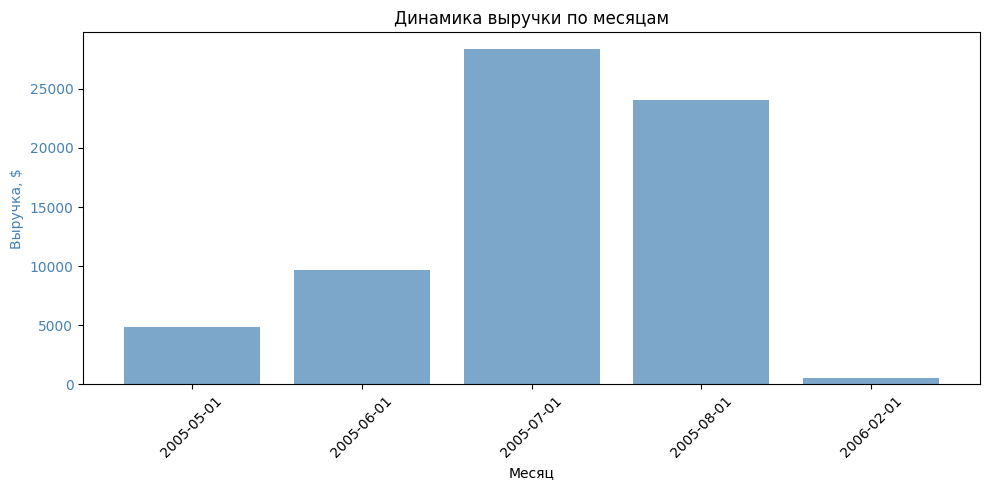

In [10]:
import matplotlib.pyplot as plt

with target_engine.connect() as conn:
    df_plot = pd.read_sql(text("""
        SELECT report_month, total_revenue, total_rentals
        FROM monthly_report
        ORDER BY report_month
    """), conn)

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.bar(df_plot['report_month'].astype(str), df_plot['total_revenue'], color='steelblue', alpha=0.7)
ax1.set_xlabel('Месяц')
ax1.set_ylabel('Выручка, $', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.set_title('Динамика выручки по месяцам')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [11]:
max_rentals_month = df_plot.loc[df_plot['total_rentals'].idxmax()]
print(f"Месяц с максимальным количеством аренд: {max_rentals_month['report_month']} ({max_rentals_month['total_rentals']} аренд)")

Месяц с максимальным количеством аренд: 2005-07-01 (6709 аренд)


In [12]:
top_cats_query = """
WITH all_rentals AS (
    SELECT fc.category_id
    FROM rental r
    JOIN inventory i ON r.inventory_id = i.inventory_id
    JOIN film_category fc ON i.film_id = fc.film_id
)
SELECT c.name, COUNT(*) AS cnt
FROM all_rentals ar
JOIN category c ON ar.category_id = c.category_id
GROUP BY c.name
ORDER BY cnt DESC
LIMIT 3
"""

with source_engine.connect() as conn:
    df_top_cats = pd.read_sql(text(top_cats_query), conn)

print("Топ-3 категории за весь период:")
print(df_top_cats)

Топ-3 категории за весь период:
        name   cnt
0     Sports  1179
1  Animation  1166
2     Action  1112


Скользящее среднее (3 месяца) для avg_rental_duration:
  report_month  avg_rental_duration  moving_avg_3m
0   2005-05-01                 4.43       4.430000
1   2005-06-01                 4.54       4.485000
2   2005-07-01                 4.52       4.496667
3   2005-08-01                 4.55       4.536667
4   2006-02-01                 0.00       3.023333


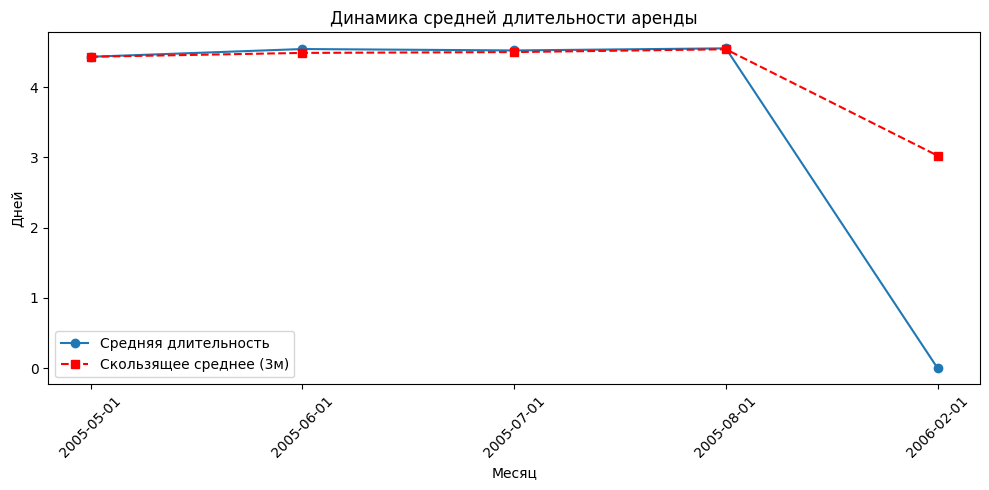

In [13]:
with target_engine.connect() as conn:
    df_ma = pd.read_sql(text("""
        SELECT 
            report_month,
            avg_rental_duration,
            AVG(avg_rental_duration) OVER (ORDER BY report_month ROWS BETWEEN 2 PRECEDING AND CURRENT ROW) AS moving_avg_3m
        FROM monthly_report
        ORDER BY report_month
    """), conn)

print("Скользящее среднее (3 месяца) для avg_rental_duration:")
print(df_ma)

# График
plt.figure(figsize=(10, 5))
plt.plot(df_ma['report_month'].astype(str), df_ma['avg_rental_duration'], 'o-', label='Средняя длительность')
plt.plot(df_ma['report_month'].astype(str), df_ma['moving_avg_3m'], 's--', color='red', label='Скользящее среднее (3м)')
plt.xlabel('Месяц')
plt.ylabel('Дней')
plt.title('Динамика средней длительности аренды')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [14]:
from sqlalchemy import create_engine, text
import pandas as pd
from datetime import datetime
from tqdm.notebook import tqdm

class MetricsCalculator:
    def __init__(self, source_engine):
        self.source_engine = source_engine
    
    def calculate_month_metrics(self, report_date_str):
        query = f"""
        WITH 
        month_rentals AS (
            SELECT 
                r.rental_id, r.customer_id, r.rental_date, r.return_date,
                EXTRACT(DAY FROM r.return_date - r.rental_date) AS rental_days,
                p.amount, i.film_id
            FROM rental r
            LEFT JOIN payment p ON r.rental_id = p.rental_id
            LEFT JOIN inventory i ON r.inventory_id = i.inventory_id
            WHERE DATE_TRUNC('month', r.rental_date) = '{report_date_str}'::date
        ),
        top_films AS (
            SELECT f.title, COUNT(*) AS cnt
            FROM month_rentals mr
            JOIN film f ON mr.film_id = f.film_id
            GROUP BY f.title ORDER BY cnt DESC, f.title LIMIT 5
        ),
        top_cats AS (
            SELECT c.name, COUNT(*) AS cnt
            FROM month_rentals mr
            JOIN film_category fc ON mr.film_id = fc.film_id
            JOIN category c ON fc.category_id = c.category_id
            GROUP BY c.name ORDER BY cnt DESC, c.name LIMIT 5
        ),
        films_no_rent AS (
            SELECT COUNT(*) AS cnt FROM film f
            WHERE NOT EXISTS (SELECT 1 FROM month_rentals mr WHERE mr.film_id = f.film_id)
        ),
        new_cust AS (
            SELECT COUNT(*) AS cnt FROM customer
            WHERE DATE_TRUNC('month', create_date) = '{report_date_str}'::date
        ),
        churned AS (
            SELECT COUNT(DISTINCT c.customer_id) AS cnt
            FROM customer c
            WHERE EXISTS (SELECT 1 FROM rental r WHERE r.customer_id = c.customer_id 
                         AND DATE_TRUNC('month', r.rental_date) < '{report_date_str}'::date)
            AND NOT EXISTS (SELECT 1 FROM rental r WHERE r.customer_id = c.customer_id 
                            AND DATE_TRUNC('month', r.rental_date) = '{report_date_str}'::date)
        ),
        returns_metrics AS (
            SELECT 
                COUNT(*) FILTER (WHERE rental_days <= 7) AS on_time_returns,
                COUNT(*) FILTER (WHERE rental_days > 7) AS late_returns,
                COUNT(*) FILTER (WHERE return_date IS NULL 
                                 AND EXTRACT(DAY FROM NOW() - rental_date) > 30) AS lost_films
            FROM month_rentals
        )
        SELECT 
            mr.total_rentals, mr.unique_customers, mr.avg_rental_duration, mr.total_revenue,
            mr.total_revenue / NULLIF(mr.total_rentals, 0) AS avg_revenue_per_rental,
            COALESCE((SELECT STRING_AGG(title, ', ' ORDER BY cnt DESC, title) FROM top_films), '') AS top_5_films,
            COALESCE((SELECT STRING_AGG(name, ', ' ORDER BY cnt DESC, name) FROM top_cats), '') AS top_5_categories,
            (SELECT cnt FROM films_no_rent) AS films_without_rentals,
            (SELECT cnt FROM new_cust) AS new_customers,
            (SELECT cnt FROM churned) AS churned_customers,
            mr.total_rentals::float / NULLIF(mr.unique_customers, 0) AS avg_rentals_per_customer,
            rm.on_time_returns, rm.late_returns, rm.lost_films
        FROM (
            SELECT 
                COUNT(*) AS total_rentals,
                COUNT(DISTINCT customer_id) AS unique_customers,
                AVG(rental_days) AS avg_rental_duration,
                COALESCE(SUM(amount), 0) AS total_revenue
            FROM month_rentals
        ) mr
        CROSS JOIN returns_metrics rm
        """
        with self.source_engine.connect() as conn:
            df = pd.read_sql(text(query), conn)
        row = df.iloc[0]
        return {
            'report_month': report_date_str,
            'report_year': pd.to_datetime(report_date_str).year,
            'report_month_num': pd.to_datetime(report_date_str).month,
            'total_rentals': int(row['total_rentals']),
            'unique_customers': int(row['unique_customers']),
            'avg_rental_duration': float(row['avg_rental_duration']) if row['avg_rental_duration'] else 0,
            'total_revenue': float(row['total_revenue']),
            'avg_revenue_per_rental': float(row['avg_revenue_per_rental']) if row['avg_revenue_per_rental'] else 0,
            'top_5_films': row['top_5_films'],
            'top_5_categories': row['top_5_categories'],
            'films_without_rentals': int(row['films_without_rentals']),
            'new_customers': int(row['new_customers']),
            'churned_customers': int(row['churned_customers']),
            'avg_rentals_per_customer': float(row['avg_rentals_per_customer']) if row['avg_rentals_per_customer'] else 0,
            'on_time_returns': int(row['on_time_returns']),
            'late_returns': int(row['late_returns']),
            'lost_films': int(row['lost_films'])
        }


def save_monthly_report(target_engine, metrics):
    insert_query = text("""
        INSERT INTO monthly_report (
            report_month, report_year, report_month_num,
            total_rentals, unique_customers, avg_rental_duration,
            total_revenue, avg_revenue_per_rental,
            top_5_films, top_5_categories, films_without_rentals,
            new_customers, churned_customers, avg_rentals_per_customer,
            on_time_returns, late_returns, lost_films,
            etl_timestamp, etl_status
        ) VALUES (
            :report_month, :report_year, :report_month_num,
            :total_rentals, :unique_customers, :avg_rental_duration,
            :total_revenue, :avg_revenue_per_rental,
            :top_5_films, :top_5_categories, :films_without_rentals,
            :new_customers, :churned_customers, :avg_rentals_per_customer,
            :on_time_returns, :late_returns, :lost_films,
            NOW(), 'SUCCESS'
        )
        ON CONFLICT (report_month) DO UPDATE SET
            total_rentals = EXCLUDED.total_rentals,
            unique_customers = EXCLUDED.unique_customers,
            avg_rental_duration = EXCLUDED.avg_rental_duration,
            total_revenue = EXCLUDED.total_revenue,
            avg_revenue_per_rental = EXCLUDED.avg_revenue_per_rental,
            top_5_films = EXCLUDED.top_5_films,
            top_5_categories = EXCLUDED.top_5_categories,
            films_without_rentals = EXCLUDED.films_without_rentals,
            new_customers = EXCLUDED.new_customers,
            churned_customers = EXCLUDED.churned_customers,
            avg_rentals_per_customer = EXCLUDED.avg_rentals_per_customer,
            on_time_returns = EXCLUDED.on_time_returns,
            late_returns = EXCLUDED.late_returns,
            lost_films = EXCLUDED.lost_films,
            etl_timestamp = NOW(),
            etl_status = 'UPDATED'
    """)
    with target_engine.connect() as conn:
        conn.execute(insert_query, metrics)
        conn.commit()


def run_full_etl(source_engine, target_engine):
    calc = MetricsCalculator(source_engine)
    
    # Получаем список месяцев
    with source_engine.connect() as conn:
        df_months = pd.read_sql(text("""
            SELECT DISTINCT DATE_TRUNC('month', rental_date)::date AS month_start
            FROM rental ORDER BY month_start
        """), conn)
    
    print(f"Найдено месяцев: {len(df_months)}")
    
    for _, row in tqdm(df_months.iterrows(), total=len(df_months), desc="ETL"):
        month_date = row['month_start'].strftime('%Y-%m-%d')
        try:
            metrics = calc.calculate_month_metrics(month_date)
            save_monthly_report(target_engine, metrics)
        except Exception as e:
            print(f"Ошибка за {month_date}: {e}")
    
    print("✅ ETL завершён")


# Запуск
run_full_etl(source_engine, target_engine)

Найдено месяцев: 5


ETL:   0%|          | 0/5 [00:00<?, ?it/s]

✅ ETL завершён


In [15]:
def incremental_etl(source_engine, target_engine):
    calc = MetricsCalculator(source_engine)
    
    # Последний месяц в отчёте
    with target_engine.connect() as conn:
        last_month = conn.execute(text("""
            SELECT MAX(report_month) FROM monthly_report WHERE etl_status = 'SUCCESS'
        """)).scalar()
    
    # Все месяцы с арендами
    with source_engine.connect() as conn:
        df_all = pd.read_sql(text("""
            SELECT DISTINCT DATE_TRUNC('month', rental_date)::date AS month_start
            FROM rental ORDER BY month_start
        """), conn)
    
    # Фильтруем новые месяцы
    if last_month:
        df_new = df_all[df_all['month_start'] > pd.to_datetime(last_month)]
        print(f"Последний загруженный: {last_month}")
    else:
        df_new = df_all
        print("Первая загрузка")
    
    print(f"Новых месяцев: {len(df_new)}")
    
    for _, row in tqdm(df_new.iterrows(), total=len(df_new), desc="Incremental ETL"):
        month_date = row['month_start'].strftime('%Y-%m-%d')
        try:
            metrics = calc.calculate_month_metrics(month_date)
            save_monthly_report(target_engine, metrics)
        except Exception as e:
            print(f"Ошибка за {month_date}: {e}")
    
    print("✅ Инкрементальный ETL завершён")

# Запуск
incremental_etl(source_engine, target_engine)

Первая загрузка
Новых месяцев: 5


Incremental ETL:   0%|          | 0/5 [00:00<?, ?it/s]

✅ Инкрементальный ETL завершён
